# 🌸 TP — Modèles Supervisés
## Partie 1 — Fondamentaux du Machine Learning | CD2IA | Metz Numeric School

---

### 🎯 Objectif
Mettre en pratique les modèles supervisés vus en cours sur deux datasets exemples.

Le TP se déroule en deux parties :
1. **Classification** sur le dataset Iris — comparer 6 modèles
2. **Régression** sur le dataset Diabetes — évaluer avec le R²

### 📋 Sommaire
1. 📦 Imports
2. 🌸 Classification — Dataset Iris
3. 🔲 Matrices de confusion
4. 📈 Régression — Dataset Diabetes
5. 📋 Conclusion


## 📦 1. Imports


Je regroupe tous mes imports dans une seule cellule.


In [ ]:
import numpy as np                            # calcul numérique
import pandas as pd                           # manipulation des données
import matplotlib.pyplot as plt               # graphiques

# ── Modèles ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression  # régression linéaire et logistique
from sklearn.svm import SVC                                             # Support Vector Machine
from sklearn.naive_bayes import GaussianNB                              # classification naïve bayésienne
from sklearn.tree import DecisionTreeClassifier                         # arbre de décision
from sklearn.ensemble import RandomForestClassifier                     # forêt aléatoire
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis    # LDA

# ── Préparation des données ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split                    # séparer les données
from sklearn.preprocessing import StandardScaler                        # normalisation
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes  # datasets exemples

# ── Métriques ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,           # exactitude
    precision_score,          # précision
    recall_score,             # rappel
    f1_score,                 # F1-score
    confusion_matrix,         # matrice de confusion
    ConfusionMatrixDisplay,   # affichage matrice de confusion
    r2_score,                 # R² pour la régression
    classification_report     # rapport complet
)

# ── Affichage dynamique ───────────────────────────────────────────────────────
from IPython.display import Markdown, display                           # afficher du markdown


## 🌸 2. Classification — Dataset Iris


Je compare **6 modèles de classification** sur le dataset Iris : Régression Logistique, SVM, Naive Bayes, Arbre de Décision, Random Forest et LDA.


Dimensions : (150, 4)
Classes : ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 📊 Comparaison des modèles — Classification (Iris)

,Accuracy,Précision,Rappel,F1-Score
LDA,1.0000,1.0000,1.0000,1.0000
SVM,0.9667,0.9697,0.9667,0.9666
Naive Bayes,0.9667,0.9697,0.9667,0.9666
Régression Logistique,0.9333,0.9333,0.9333,0.9333
Arbre de Décision,0.9333,0.9333,0.9333,0.9333
Random Forest,0.9000,0.9024,0.9000,0.8997


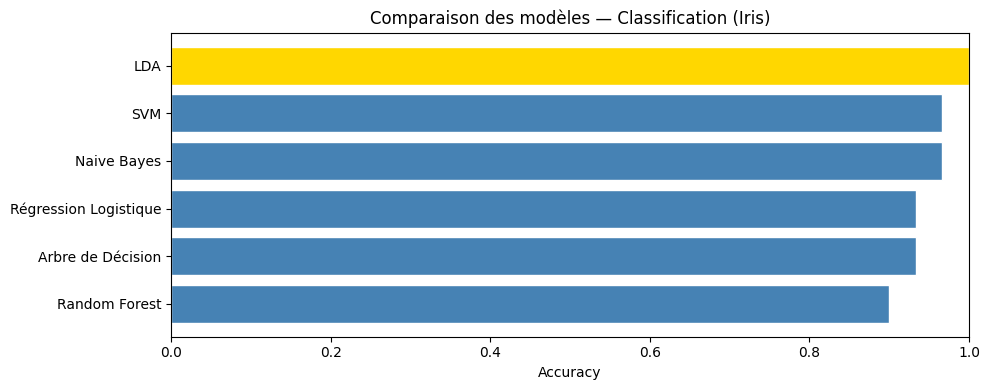

In [ ]:
# ─── Chargement du dataset Iris ───────────────────────────────────────────────
iris   = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print(f"Dimensions : {X_iris.shape}")
print(f"Classes : {iris.target_names}")
display(X_iris.head())

# ─── Split train/test ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# ─── Normalisation ────────────────────────────────────────────────────────────
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)  # fit + transform sur le train
X_test_sc     = scaler.transform(X_test)        # transform uniquement sur le test

# ─── Entraînement de plusieurs modèles ───────────────────────────────────────
modeles = {
    'Régression Logistique' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'                   : SVC(kernel='rbf', random_state=42),
    'Naive Bayes'           : GaussianNB(),
    'Arbre de Décision'     : DecisionTreeClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
    'LDA'                   : LinearDiscriminantAnalysis(),
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train_sc, y_train)
    y_pred = modele.predict(X_test_sc)
    resultats[nom] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Précision' : precision_score(y_test, y_pred, average='weighted'),
        'Rappel'    : recall_score(y_test, y_pred, average='weighted'),
        'F1-Score'  : f1_score(y_test, y_pred, average='weighted'),
    }

# ─── Tableau comparatif ───────────────────────────────────────────────────────
resultats_df = pd.DataFrame(resultats).T.round(4)
resultats_df = resultats_df.sort_values('Accuracy', ascending=False)

display(Markdown("### 📊 Comparaison des modèles — Classification (Iris)"))
display(resultats_df)

# ─── Graphique ────────────────────────────────────────────────────────────────
meilleur = resultats_df.index[0]
couleurs = ['gold' if m == meilleur else 'steelblue' for m in resultats_df.index]

plt.figure(figsize=(10, 4))
plt.barh(resultats_df.index[::-1], resultats_df['Accuracy'][::-1],
         color=couleurs[::-1], edgecolor='white')
plt.xlabel('Accuracy')
plt.title('Comparaison des modèles — Classification (Iris)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Classification (Iris)

**Résultats sur 30 articles de test (20% du dataset) :**

| Rang | Modèle | Accuracy | Précision | Rappel | F1-Score |
|------|--------|----------|-----------|--------|----------|
| 🥇 | **LDA** | **100%** | **100%** | **100%** | **100%** |
| 🥈 | SVM | 96.7% | 97.0% | 96.7% | 96.7% |
| 🥈 | Naive Bayes | 96.7% | 97.0% | 96.7% | 96.7% |
| 4 | Régression Logistique | 93.3% | 93.3% | 93.3% | 93.3% |
| 4 | Arbre de Décision | 93.3% | 93.3% | 93.3% | 93.3% |
| 6 | Random Forest | 90.0% | 90.2% | 90.0% | 90.0% |

> 💡 **LDA obtient 100%** — parfait sur ce dataset !
> C'est logique : LDA est conçu pour **maximiser la séparation entre les classes**,
> et les 3 espèces d'Iris ont des caractéristiques très bien séparées.

> ⚠️ Ces scores très élevés s'expliquent par la nature du dataset Iris —
> c'est un dataset **simple et bien séparé**, souvent utilisé comme exemple pédagogique.
> Sur un vrai dataset plus complexe, les scores seraient plus modestes.

> ⚠️ **Random Forest est le moins bon** (90%) malgré sa réputation —
> avec seulement 4 features et 120 exemples d'entraînement,
> les modèles simples comme LDA et SVM suffisent largement.


## 🔲 3. Matrices de confusion


Je visualise les **erreurs de chaque modèle** — la diagonale représente les prédictions correctes, plus elle est foncée, mieux c'est.


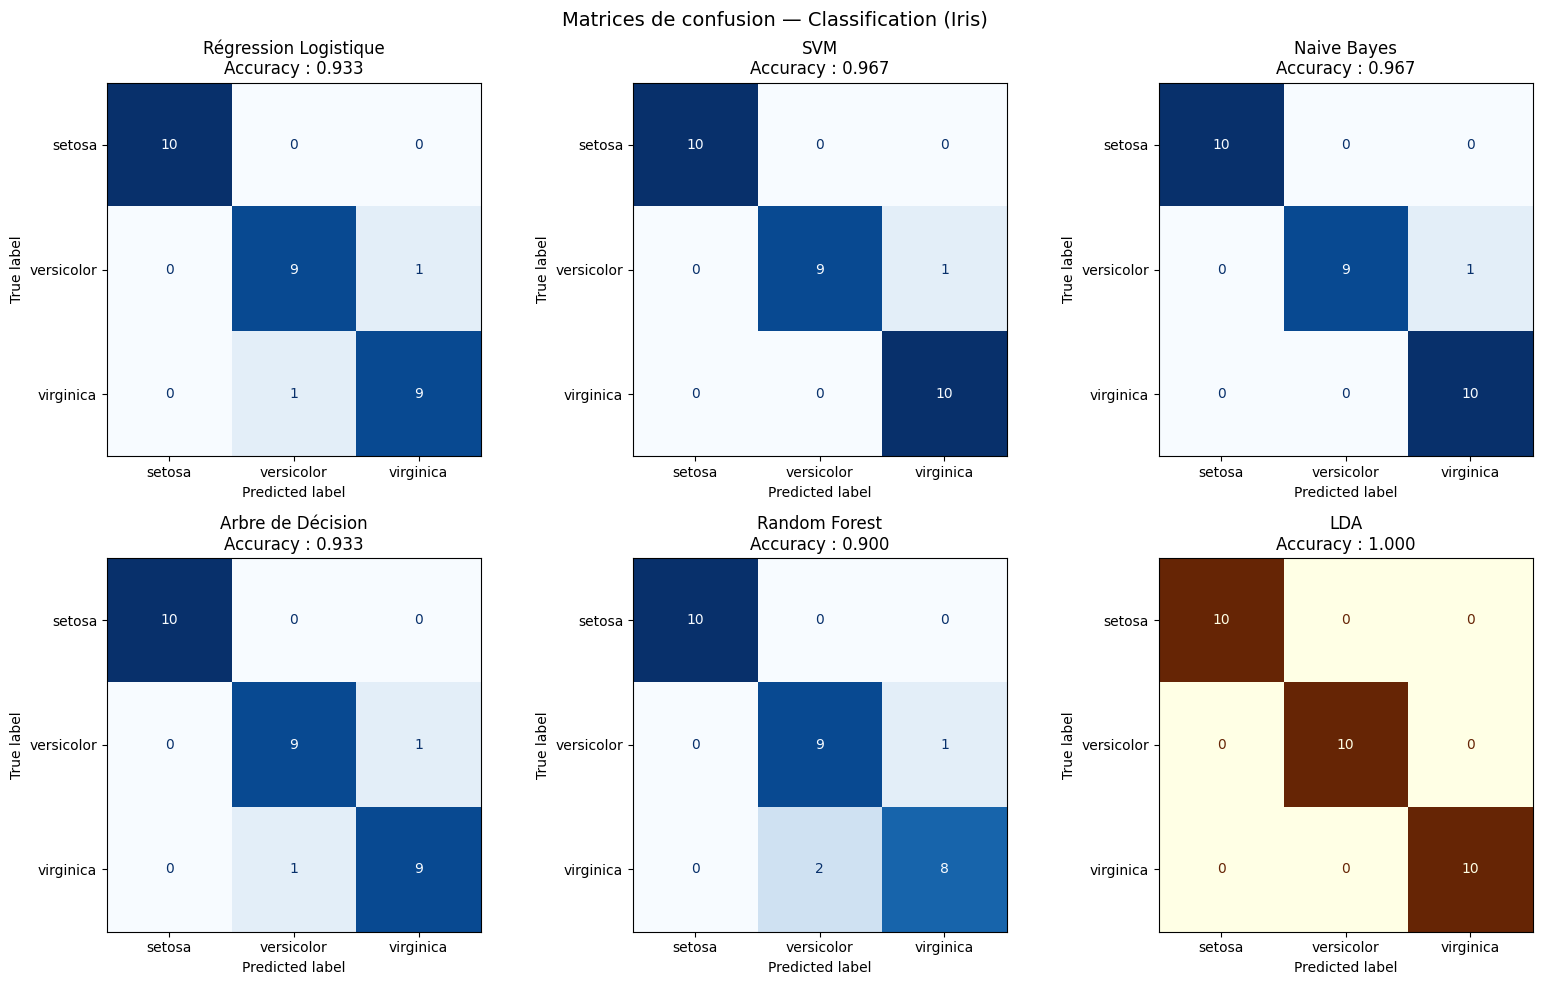

In [ ]:
# ─── Matrices de confusion ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (nom, modele) in enumerate(modeles.items()):
    y_pred = modele.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)
    cmap   = 'YlOrBr' if nom == meilleur else 'Blues'
    disp   = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap=cmap)
    axes[idx].set_title(f'{nom}\nAccuracy : {acc:.3f}')

plt.suptitle('Matrices de confusion — Classification (Iris)', fontsize=14)
plt.tight_layout()
plt.show()


📌 Ce que j'observe — Matrices de confusion

La diagonale de chaque matrice représente les **prédictions correctes** —
plus elle est foncée, mieux le modèle performe.

**LDA — 100% 🥇**
La diagonale est **entièrement foncée** — zéro erreur sur les 30 articles de test.
LDA sépare parfaitement les 3 espèces grâce à ses axes discriminants optimisés.

**SVM & Naive Bayes — 96.7%**
Une seule erreur chacun — **Virginica** confondue avec **Versicolor**.
Ces deux espèces ont des caractéristiques proches, c'est la confusion la plus fréquente sur Iris.

**Régression Logistique & Arbre de Décision — 93.3%**
Deux erreurs chacun — toujours sur la frontière **Virginica / Versicolor**.

**Random Forest — 90%**
Trois erreurs — le moins bon malgré sa complexité.
Avec seulement **4 features** et **120 exemples**, les modèles simples suffisent.

| Modèle | Erreurs | Confusion principale |
|--------|---------|---------------------|
| LDA | **0** | — |
| SVM | 1 | Virginica → Versicolor |
| Naive Bayes | 1 | Virginica → Versicolor |
| Régression Logistique | 2 | Virginica → Versicolor |
| Arbre de Décision | 2 | Virginica → Versicolor |
| Random Forest | 3 | Virginica → Versicolor |

> 💡 La classe **Setosa** est parfaitement classée par **tous** les modèles —
> elle est très distincte des deux autres. La difficulté vient uniquement
> de la frontière **Virginica / Versicolor** qui se chevauche légèrement.


## 📈 4. Régression — Dataset Diabetes


Je teste la **Régression Linéaire** sur le dataset Diabetes.
La cible est une valeur **numérique continue** — pas une catégorie.

> 💡 Pour la régression, j'utilise le **R²** au lieu de l'accuracy :
> - **R² = 1.0** → prédiction parfaite
> - **R² = 0.0** → pas mieux que prédire la moyenne
> - **R² < 0.0** → pire que la moyenne


Dimensions : (442, 10)
Cible (exemple) : [151.  75. 141. 206. 135.]


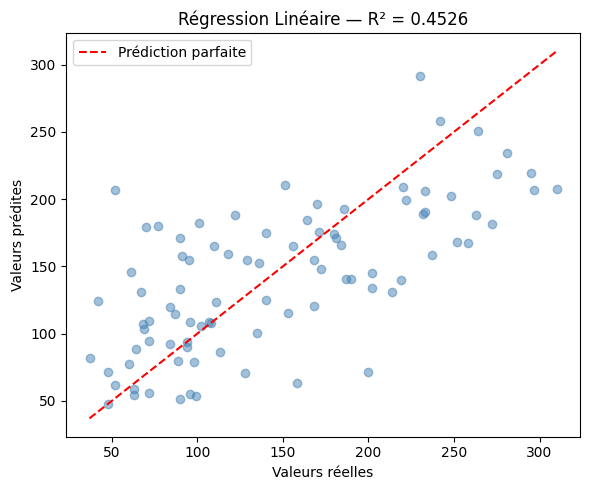


### 📌 Résultat Régression Linéaire
- **R² = 0.4526**
- Le modèle explique **45.3%** de la variance des données


In [ ]:
# ─── Chargement du dataset Diabetes ──────────────────────────────────────────
diabetes    = load_diabetes()
X_diab      = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diab      = diabetes.target   # valeur numérique de progression du diabète

print(f"Dimensions : {X_diab.shape}")
print(f"Cible (exemple) : {y_diab[:5]}")

# ─── Split train/test ─────────────────────────────────────────────────────────
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

# ─── Régression Linéaire ──────────────────────────────────────────────────────
reg   = LinearRegression()
reg.fit(X_tr_d, y_tr_d)
y_pred_reg = reg.predict(X_te_d)
r2         = r2_score(y_te_d, y_pred_reg)

# ─── Visualisation : valeurs réelles vs prédites ──────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(y_te_d, y_pred_reg, alpha=0.5, color='steelblue')
plt.plot([y_te_d.min(), y_te_d.max()],
         [y_te_d.min(), y_te_d.max()], 'r--', label='Prédiction parfaite')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title(f'Régression Linéaire — R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""
### 📌 Résultat Régression Linéaire
- **R² = {r2:.4f}**
- Le modèle explique **{r2:.1%}** de la variance des données
"""))


📌 Ce que j'observe — Régression (Diabetes)

**R² = 0.4526** → le modèle explique **45.3%** de la variance des données.

| Évaluation | Interprétation |
|------------|----------------|
| R² = 0.45 | Performance **moyenne** — acceptable mais perfectible |
| Points éparpillés | Le modèle prédit dans la bonne direction mais avec imprécision |
| Tendance visible | La relation linéaire existe mais est **partielle** |

> 💡 Un R² de 0.45 sur des données médicales n'est pas si mauvais —
> la progression du diabète dépend de nombreux facteurs que les
> 10 features du dataset ne capturent pas tous.

> 💡 **Comparaison Classification vs Régression** :
> - Classification (Iris) : 90-100% — problème bien défini
> - Régression (Diabetes) : 45% — problème plus complexe, valeur continue


## 📋 5. Conclusion


### 🔑 Bilan du TP

**Classification — Dataset Iris :**

| Rang | Modèle | Accuracy | Précision | Rappel | F1-Score |
|------|--------|----------|-----------|--------|----------|
| 🥇 | **LDA** | **100%** | **100%** | **100%** | **100%** |
| 🥈 | SVM | 96.7% | 97.0% | 96.7% | 96.7% |
| 🥈 | Naive Bayes | 96.7% | 97.0% | 96.7% | 96.7% |
| 4 | Régression Logistique | 93.3% | 93.3% | 93.3% | 93.3% |
| 4 | Arbre de Décision | 93.3% | 93.3% | 93.3% | 93.3% |
| 6 | Random Forest | 90.0% | 90.2% | 90.0% | 90.0% |

**Régression — Dataset Diabetes :**

| Modèle | R² |
|--------|----|
| Régression Linéaire | **0.4526** — explique 45.3% de la variance |

**Enseignements :**
- **LDA** est parfait sur Iris car les 3 espèces sont bien séparées
- La confusion se concentre toujours sur la frontière **Virginica / Versicolor**
- **Setosa** est parfaitement classée par tous les modèles
- Un R² de 0.45 sur des données médicales est raisonnable — la progression du diabète
  dépend de nombreux facteurs non capturés dans les 10 features du dataset
- **Règle d'or** : il n'existe pas de modèle universel !
